In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

# Bugün ne yapacağız?
print("Transfer Learning Planı:")
print("1. CIFAR-10 veri setini yükle (10 farklı nesne sınıfı)")
print("2. ResNet18 modelini indir (ImageNet'te eğitilmiş)")
print("3. Son katmanı değiştir (1000 sınıf → 10 sınıf)")
print("4. Eğit ve karşılaştır:")
print("   - Sıfırdan eğitim vs Transfer Learning")
print("\nPyTorch versiyonu:", torch.__version__)
print("Torchvision versiyonu:", torchvision.__version__)

Transfer Learning Planı:
1. CIFAR-10 veri setini yükle (10 farklı nesne sınıfı)
2. ResNet18 modelini indir (ImageNet'te eğitilmiş)
3. Son katmanı değiştir (1000 sınıf → 10 sınıf)
4. Eğit ve karşılaştır:
   - Sıfırdan eğitim vs Transfer Learning

PyTorch versiyonu: 2.10.0+cpu
Torchvision versiyonu: 0.25.0+cpu


In [2]:
# CIFAR-10 için özel transform — ResNet 224x224 bekliyor
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),   # Veri artırımı
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],      # ImageNet ortalaması
        std=[0.229, 0.224, 0.225]        # ImageNet std
    )
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Veriyi indir
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# CPU'da hızlı çalışmak için küçük subset alalım
train_subset = torch.utils.data.Subset(train_dataset, range(2000))
test_subset = torch.utils.data.Subset(test_dataset, range(400))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=32, shuffle=False)

classes = ['uçak', 'araba', 'kuş', 'kedi', 'geyik',
           'köpek', 'kurbağa', 'at', 'gemi', 'kamyon']

print("Train subset:", len(train_subset), "örnek")
print("Test subset:", len(test_subset), "örnek")
print("Sınıflar:", classes)

100.0%
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train subset: 2000 örnek
Test subset: 400 örnek
Sınıflar: ['uçak', 'araba', 'kuş', 'kedi', 'geyik', 'köpek', 'kurbağa', 'at', 'gemi', 'kamyon']


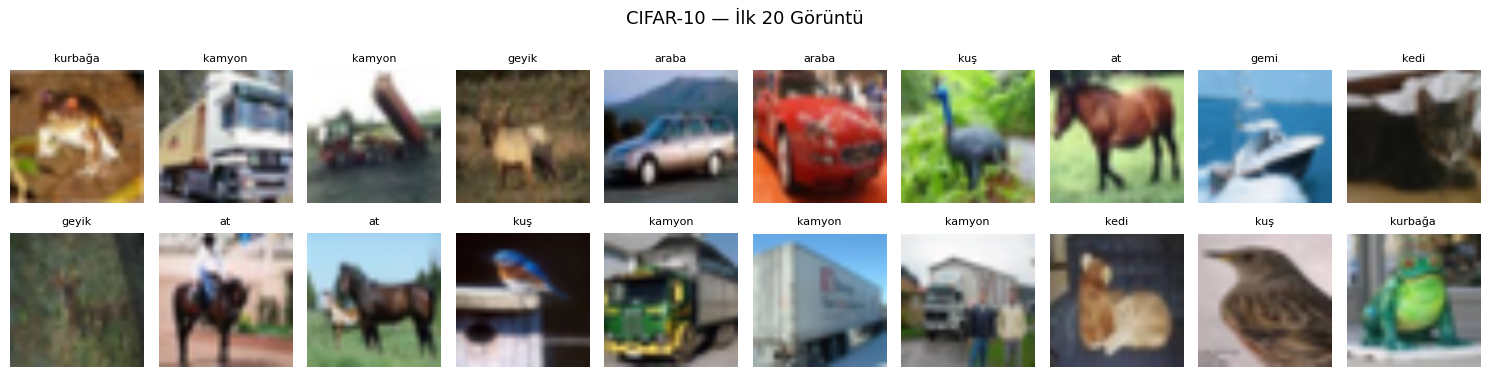

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]
    # Normalize edilmiş görüntüyü geri al
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.permute(1, 2, 0).clip(0, 1)
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.suptitle("CIFAR-10 — İlk 20 Görüntü", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# ImageNet'te eğitilmiş ResNet18'i indir
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modelin yapısına bakalım
print("ResNet18 son katmanı:", resnet.fc)
print("Toplam parametre:", sum(p.numel() for p in resnet.parameters()))

# Son katmanı dondur — sadece son katmanı eğiteceğiz
for param in resnet.parameters():
    param.requires_grad = False

# Son katmanı değiştir: 1000 → 10 sınıf
resnet.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

# Sadece yeni katmanın parametreleri eğitilecek
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())

print("\nDeğiştirilen son katman:", resnet.fc)
print(f"\nEğitilecek parametre: {trainable:,}")
print(f"Toplam parametre: {total:,}")
print(f"Dondurulmuş oran: {(total-trainable)/total:.1%}")

0.8%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\PC/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet18 son katmanı: Linear(in_features=512, out_features=1000, bias=True)
Toplam parametre: 11689512

Değiştirilen son katman: Sequential(
  (0): Linear(in_features=512, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=128, out_features=10, bias=True)
)

Eğitilecek parametre: 66,954
Toplam parametre: 11,243,466
Dondurulmuş oran: 99.4%


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=0.001
)

tl_train_losses, tl_test_losses = [], []
tl_train_accs, tl_test_accs = [], []

print("Transfer Learning eğitimi başlıyor...")

for epoch in range(5):
    # Eğitim
    resnet.train()
    total_loss, correct = 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = resnet(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / len(train_subset)

    # Test
    resnet.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = resnet(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()

    test_loss = total_loss / len(test_loader)
    test_acc = correct / len(test_subset)

    tl_train_losses.append(train_loss)
    tl_test_losses.append(test_loss)
    tl_train_accs.append(train_acc)
    tl_test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/5 | Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} Acc: {test_acc:.2%}")

Transfer Learning eğitimi başlıyor...
Epoch 1/5 | Train Loss: 1.7590 Acc: 40.60% | Test Loss: 1.3664 Acc: 58.75%
Epoch 2/5 | Train Loss: 1.1358 Acc: 62.85% | Test Loss: 1.0230 Acc: 66.50%
Epoch 3/5 | Train Loss: 0.9394 Acc: 67.80% | Test Loss: 0.9185 Acc: 69.50%
Epoch 4/5 | Train Loss: 0.8237 Acc: 72.50% | Test Loss: 0.8510 Acc: 72.25%
Epoch 5/5 | Train Loss: 0.7842 Acc: 73.05% | Test Loss: 0.8125 Acc: 71.50%


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

scratch_model = SimpleCNN()
scratch_optimizer = torch.optim.Adam(scratch_model.parameters(), lr=0.001)

scratch_train_accs, scratch_test_accs = [], []

print("Sıfırdan eğitim başlıyor...")

for epoch in range(5):
    # Eğitim
    scratch_model.train()
    total_loss, correct = 0, 0

    for X_batch, y_batch in train_loader:
        scratch_optimizer.zero_grad()
        output = scratch_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        scratch_optimizer.step()
        correct += (output.argmax(1) == y_batch).sum().item()

    train_acc = correct / len(train_subset)

    # Test
    scratch_model.eval()
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = scratch_model(X_batch)
            correct += (output.argmax(1) == y_batch).sum().item()

    test_acc = correct / len(test_subset)
    scratch_train_accs.append(train_acc)
    scratch_test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/5 | Train Acc: {train_acc:.2%} | Test Acc: {test_acc:.2%}")

Sıfırdan eğitim başlıyor...
Epoch 1/5 | Train Acc: 23.30% | Test Acc: 31.25%
Epoch 2/5 | Train Acc: 34.50% | Test Acc: 31.50%
Epoch 3/5 | Train Acc: 41.75% | Test Acc: 38.75%
Epoch 4/5 | Train Acc: 45.30% | Test Acc: 41.50%
Epoch 5/5 | Train Acc: 48.35% | Test Acc: 38.25%


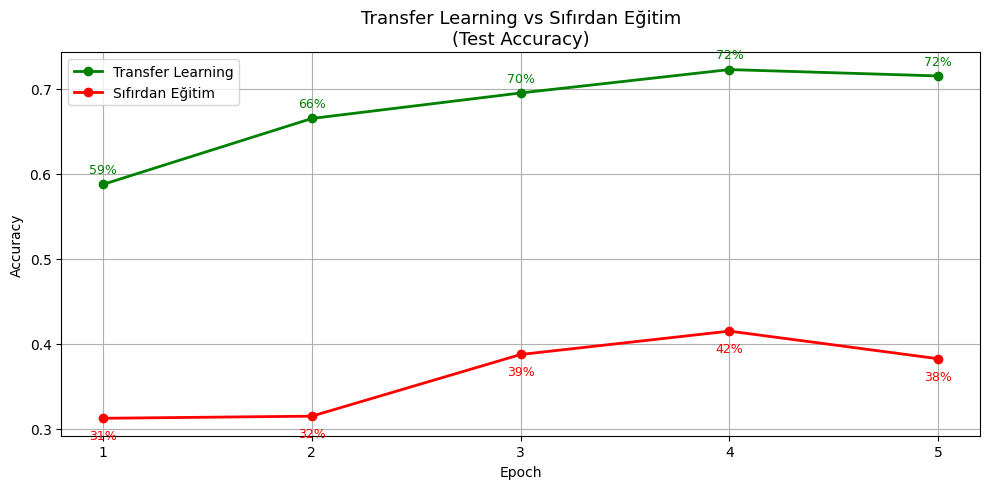

In [7]:
plt.figure(figsize=(10, 5))

epochs = range(1, 6)

plt.plot(epochs, tl_test_accs, 'g-o', label='Transfer Learning', linewidth=2)
plt.plot(epochs, scratch_test_accs, 'r-o', label='Sıfırdan Eğitim', linewidth=2)

plt.title("Transfer Learning vs Sıfırdan Eğitim\n(Test Accuracy)", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

for i, (tl, sc) in enumerate(zip(tl_test_accs, scratch_test_accs)):
    plt.annotate(f'{tl:.0%}', (i+1, tl), textcoords="offset points",
                xytext=(0, 8), ha='center', color='green', fontsize=9)
    plt.annotate(f'{sc:.0%}', (i+1, sc), textcoords="offset points",
                xytext=(0, -15), ha='center', color='red', fontsize=9)

plt.tight_layout()
plt.show()